# LINK TO APP!!!!

# https://anime-high-score-predictor-streamlit.onrender.com

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import joblib

import os

In [5]:
data_path = "../data/raw/anime-standalone.csv"

df = pd.read_csv(data_path)

df.head()

,id,title,titleJa,titleEn,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios
0,1,Cowboy Bebop,カウボーイビバップ,Cowboy Bebop,https://myanimelist.net/images/anime/4/19644.jpg,8.75,49.0,2051529,1059425,26,1998-04-03,1999-04-24,tv,finished_airing,r,1440,"Action, Adult Cast, Award Winning, Sci-Fi, Space",Sunrise
1,5,Cowboy Bebop: Tengoku no Tobira,カウボーイビバップ 天国の扉,Cowboy Bebop: The Movie,https://myanimelist.net/images/anime/1439/9348...,8.38,240.0,411130,231859,1,2001-09-01,2001-09-01,movie,finished_airing,r,6911,"Action, Adult Cast, Sci-Fi, Space",Bones
2,6,Trigun,トライガン,Trigun,https://myanimelist.net/images/anime/1130/1200...,8.22,419.0,832704,400891,26,1998-04-01,1998-09-30,tv,finished_airing,pg_13,1480,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",Madhouse
3,7,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),Witch Hunter Robin,https://myanimelist.net/images/anime/10/19969.jpg,7.25,3527.0,129287,46530,26,2002-07-03,2002-12-25,tv,finished_airing,pg_13,1500,"Action, Detective, Drama, Mystery, Supernatural",Sunrise
4,8,Bouken Ou Beet,冒険王ビィト,Beet the Vandel Buster,https://myanimelist.net/images/anime/7/21569.webp,7.01,4893.0,16881,7226,52,2004-09-30,2005-09-29,tv,finished_airing,pg,1380,"Action, Adventure, Fantasy, Shounen",Toei Animation


In [6]:
print("Filas y columnas:", df.shape)

print("\nColumnas:")
print(df.columns.tolist())

df.info()

Filas y columnas: (24923, 18)

Columnas:
['id', 'title', 'titleJa', 'titleEn', 'image', 'mean', 'rank', 'num_list_users', 'num_scoring_users', 'num_episodes', 'start_date', 'end_date', 'media_type', 'status', 'rating', 'average_episode_duration', 'genres', 'studios']
<class 'pandas.DataFrame'>
RangeIndex: 24923 entries, 0 to 24922
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        24923 non-null  int64  
 1   title                     24923 non-null  str    
 2   titleJa                   24827 non-null  str    
 3   titleEn                   11964 non-null  str    
 4   image                     24817 non-null  str    
 5   mean                      18938 non-null  float64
 6   rank                      18157 non-null  float64
 7   num_list_users            24923 non-null  int64  
 8   num_scoring_users         24923 non-null  int64  
 9   num_episodes            

In [7]:
df["score"] = df["mean"]

df[["title", "mean", "score"]].head()

,title,mean,score
0,Cowboy Bebop,8.75,8.75
1,Cowboy Bebop: Tengoku no Tobira,8.38,8.38
2,Trigun,8.22,8.22
3,Witch Hunter Robin,7.25,7.25
4,Bouken Ou Beet,7.01,7.01


In [8]:
df["high_score"] = np.where(df["score"] >= 8, 1, 0)

df[["title", "score", "high_score"]].head()

,title,score,high_score
0,Cowboy Bebop,8.75,1
1,Cowboy Bebop: Tengoku no Tobira,8.38,1
2,Trigun,8.22,1
3,Witch Hunter Robin,7.25,0
4,Bouken Ou Beet,7.01,0


In [9]:
df["high_score"].value_counts(normalize=True)

high_score
0    0.969305
1    0.030695
Name: proportion, dtype: float64

In [10]:
numeric_features = [
    "num_list_users",
    "num_scoring_users",
    "num_episodes",
    "average_episode_duration"
]

categorical_features = [
    "media_type",
    "rating"
]

genre_column = "genres"

selected_columns = numeric_features + categorical_features + [genre_column, "high_score"]

df_model = df[selected_columns].copy()

df_model.head()

,num_list_users,num_scoring_users,num_episodes,average_episode_duration,media_type,rating,genres,high_score
0,2051529,1059425,26,1440,tv,r,"Action, Adult Cast, Award Winning, Sci-Fi, Space",1
1,411130,231859,1,6911,movie,r,"Action, Adult Cast, Sci-Fi, Space",1
2,832704,400891,26,1480,tv,pg_13,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",1
3,129287,46530,26,1500,tv,pg_13,"Action, Detective, Drama, Mystery, Supernatural",0
4,16881,7226,52,1380,tv,pg,"Action, Adventure, Fantasy, Shounen",0


In [11]:
df_model = df_model.dropna(subset=["high_score", "genres"])

df_model["media_type"] = df_model["media_type"].fillna("unknown")
df_model["rating"] = df_model["rating"].fillna("unknown")

for col in numeric_features:
    df_model[col] = df_model[col].fillna(0)

df_model.info()

<class 'pandas.DataFrame'>
Index: 24855 entries, 0 to 24922
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   num_list_users            24855 non-null  int64
 1   num_scoring_users         24855 non-null  int64
 2   num_episodes              24855 non-null  int64
 3   average_episode_duration  24855 non-null  int64
 4   media_type                24855 non-null  str  
 5   rating                    24855 non-null  str  
 6   genres                    24855 non-null  str  
 7   high_score                24855 non-null  int64
dtypes: int64(5), str(3)
memory usage: 1.7 MB


In [12]:
df_model["genres_list"] = df_model["genres"].apply(
    lambda x: [genre.strip() for genre in x.split(",")]
)

df_model[["genres", "genres_list"]].head()

,genres,genres_list
0,"Action, Adult Cast, Award Winning, Sci-Fi, Space","[Action, Adult Cast, Award Winning, Sci-Fi, Sp..."
1,"Action, Adult Cast, Sci-Fi, Space","[Action, Adult Cast, Sci-Fi, Space]"
2,"Action, Adult Cast, Adventure, Sci-Fi, Shounen","[Action, Adult Cast, Adventure, Sci-Fi, Shounen]"
3,"Action, Detective, Drama, Mystery, Supernatural","[Action, Detective, Drama, Mystery, Supernatural]"
4,"Action, Adventure, Fantasy, Shounen","[Action, Adventure, Fantasy, Shounen]"


In [13]:
all_genres = df_model["genres_list"].explode()

top_genres = all_genres.value_counts().head(15).index.tolist()

top_genres

['Comedy',
 'Music',
 'Fantasy',
 'Action',
 'Kids',
 'Adventure',
 'Sci-Fi',
 'Drama',
 'School',
 'Romance',
 'Shounen',
 'Hentai',
 'Historical',
 'Supernatural',
 'Mecha']

In [14]:
for genre in top_genres:
    df_model[f"genre_{genre}"] = df_model["genres_list"].apply(
        lambda genres: 1 if genre in genres else 0
    )

df_model.head()

,num_list_users,num_scoring_users,num_episodes,average_episode_duration,media_type,rating,genres,high_score,genres_list,genre_Comedy,...,genre_Adventure,genre_Sci-Fi,genre_Drama,genre_School,genre_Romance,genre_Shounen,genre_Hentai,genre_Historical,genre_Supernatural,genre_Mecha
0,2051529,1059425,26,1440,tv,r,"Action, Adult Cast, Award Winning, Sci-Fi, Space",1,"[Action, Adult Cast, Award Winning, Sci-Fi, Sp...",0,...,0,1,0,0,0,0,0,0,0,0
1,411130,231859,1,6911,movie,r,"Action, Adult Cast, Sci-Fi, Space",1,"[Action, Adult Cast, Sci-Fi, Space]",0,...,0,1,0,0,0,0,0,0,0,0
2,832704,400891,26,1480,tv,pg_13,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",1,"[Action, Adult Cast, Adventure, Sci-Fi, Shounen]",0,...,1,1,0,0,0,1,0,0,0,0
3,129287,46530,26,1500,tv,pg_13,"Action, Detective, Drama, Mystery, Supernatural",0,"[Action, Detective, Drama, Mystery, Supernatural]",0,...,0,0,1,0,0,0,0,0,1,0
4,16881,7226,52,1380,tv,pg,"Action, Adventure, Fantasy, Shounen",0,"[Action, Adventure, Fantasy, Shounen]",0,...,1,0,0,0,0,1,0,0,0,0


In [15]:
genre_features = [f"genre_{genre}" for genre in top_genres]

final_features = numeric_features + categorical_features + genre_features

X = df_model[final_features]

y = df_model["high_score"]

print("Features finales:")
print(final_features)

print("\nForma de X:", X.shape)
print("Forma de y:", y.shape)

Features finales:
['num_list_users', 'num_scoring_users', 'num_episodes', 'average_episode_duration', 'media_type', 'rating', 'genre_Comedy', 'genre_Music', 'genre_Fantasy', 'genre_Action', 'genre_Kids', 'genre_Adventure', 'genre_Sci-Fi', 'genre_Drama', 'genre_School', 'genre_Romance', 'genre_Shounen', 'genre_Hentai', 'genre_Historical', 'genre_Supernatural', 'genre_Mecha']

Forma de X: (24855, 21)
Forma de y: (24855,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (19884, 21)
Test: (4971, 21)


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [18]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [19]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [20]:
y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4818
           1       0.67      0.33      0.44       153

    accuracy                           0.97      4971
   macro avg       0.82      0.66      0.71      4971
weighted avg       0.97      0.97      0.97      4971

ROC-AUC: 0.9516254405456661


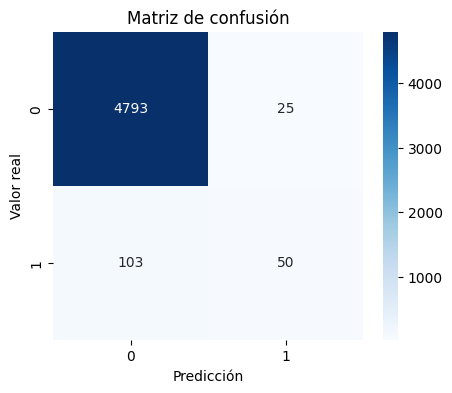

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")
plt.show()

In [22]:
model_package = {
    "model": model,
    "final_features": final_features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "top_genres": top_genres
}

joblib.dump(model_package, "../models/anime_model.pkl")

print("Modelo guardado correctamente en ../models/anime_model.pkl")

Modelo guardado correctamente en ../models/anime_model.pkl


In [23]:
loaded_package = joblib.load("../models/anime_model.pkl")

loaded_model = loaded_package["model"]
loaded_features = loaded_package["final_features"]

print("Modelo cargado correctamente.")
print("Número de features:", len(loaded_features))

Modelo cargado correctamente.
Número de features: 21


In [24]:
example = pd.DataFrame([{
    "num_list_users": 500000,
    "num_scoring_users": 200000,
    "num_episodes": 24,
    "average_episode_duration": 1440,
    "media_type": "tv",
    "rating": "pg_13",
    **{f"genre_{genre}": 0 for genre in top_genres}
}])

for genre in ["Action", "Drama", "Fantasy"]:
    col = f"genre_{genre}"
    if col in example.columns:
        example[col] = 1

example = example[loaded_features]

prediction = loaded_model.predict(example)[0]
probability = loaded_model.predict_proba(example)[0][1]

print("Predicción:", prediction)
print("Probabilidad de high_score:", probability)

Predicción: 0
Probabilidad de high_score: 0.28
